# FOMC Analysis
FOMC has eight regular meetings to determine the monetary policy. At each meeting, it publishes press conference minutes, statements as well as scripts in text. In addition to this regular meetings, the members’ speeches and testimonies are also scripted on the website.
At each meeting, the policy makers decide monetary policy and publish the decision along with their view on current economic situation and forecast, including Forward Guidance since 2012. The central banks intend to indicate their potential future monetary policy in their publications as a measure of market communication.
The objective of this project is to apply NLP on those text published by FOMC to find latent features. First, I apply machine learning to economic indices to see how the prediction performs. Then, add pre-processed text data as additional feature in traditional machine learning technique to see if it contains the meaningful information. Finally, apply Deep Learning technique such as LSTM/RNN and BERT to see if these can better predict the rate hike/lower at each FOMC meeting.
All data used in this analysis are publicly available.

<img src='../img/FomcMeetings.png' width=700>

FOMC Meeting documents are available here: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm

The process followed in this project is dipicted as follows:

<img src='../img/process.png' width=800>

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import os
import io
from dateutil.relativedelta import *

import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import pickle
from tqdm.notebook import tqdm
import re

plt.style.use('fivethirtyeight')
sns.set(style='white', context='notebook', palette='deep')
pd.options.display.max_rows = 20
%pprint

Pretty printing has been turned OFF


Run `fomc_get_calendar.py` to scrape FOMC Meeting calenadrs from FOMC wetbiste

In [2]:
file = open('../data/preprocessed/fomc_calendar.pickle', 'rb')
calendar_df = pickle.load(file)
# Convert nullable dtypes to avoid pd.NA comparison issues
import numpy as np
for col in calendar_df.columns:
    if hasattr(calendar_df[col].dtype, 'numpy_dtype') or str(calendar_df[col].dtype) in ('Int64', 'Int32', 'Float64'):
        calendar_df[col] = calendar_df[col].astype(float)
    if calendar_df[col].dtype == object:
        calendar_df[col] = calendar_df[col].where(calendar_df[col].notna(), other=np.nan)

calendar_df['RateDecision'] = calendar_df['RateDecision'].apply(lambda x: 'Raise' if not np.isnan(float(x)) and float(x)==1 else ('Lower' if not np.isnan(float(x)) and float(x)==-1 else 'Hold') if x is not None and not (isinstance(x, float) and np.isnan(x)) else 'Hold')
file.close()
calendar_df[['ChairPerson', 'RateDecision', 'Rate', 'RateDiff']].iloc[:-3]


,ChairPerson,RateDecision,Rate,RateDiff
1982-10-05,Paul Volcker,Lower,9.5,-0.5
1982-11-16,Paul Volcker,Lower,9.0,-0.5
1982-12-21,Paul Volcker,Hold,8.5,0.0
1983-01-14,Paul Volcker,Hold,8.5,0.0
1983-01-21,Paul Volcker,Hold,8.5,0.0
...,...,...,...,...
2021-01-27,Jerome Powell,Hold,NaN,NaN
2021-03-17,Jerome Powell,Hold,NaN,NaN
2021-04-28,Jerome Powell,Hold,NaN,NaN
2021-06-16,Jerome Powell,Hold,NaN,NaN


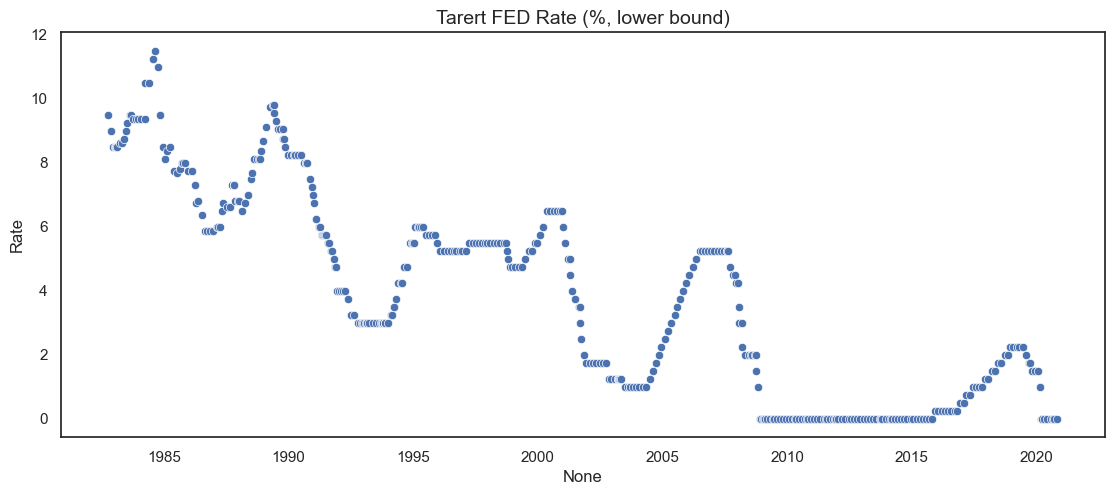

In [3]:
plt.figure(figsize=(12,5))
sns.scatterplot(x=calendar_df.index.get_level_values(0), y=calendar_df['Rate'])
plt.title('Tarert FED Rate (%, lower bound)', fontsize=14)
plt.show()

# 1. Download Economic Indices
Important economic indices are obtained from Economic Research in FRB of St. Louis Website called FRED (https://fred.stlouisfed.org/).
 - FED Target Rates (range)
 - GDP (Real, Real Estimate)
 - CPI / PCE
 - Employment and Unemployment
 - Retail Sales and Home Sales
 - ISM Purchasing Managers Index and Non-manufacturing Index

In [4]:
file = open('../data/preprocessed/nontext_data.pickle', 'rb')
meta_df = pickle.load(file)
file.close()
meta_df.columns

Index(['unscheduled', 'forecast', 'confcall', 'ChairPerson', 'Rate',
       'RateDiff', 'RateDecision', 'RateChanged', 'GDP_date', 'GDP_value',
       'GDP_diff_prev', 'GDP_diff_year', 'GDPPOT_date', 'GDPPOT_value',
       'GDPPOT_diff_prev', 'GDPPOT_diff_year', 'PCE_date', 'PCE_value',
       'PCE_diff_prev', 'PCE_diff_year', 'CPI_date', 'CPI_value',
       'CPI_diff_prev', 'CPI_diff_year', 'Unemp_date', 'Unemp_value',
       'Unemp_diff_prev', 'Unemp_diff_year', 'Employ_date', 'Employ_value',
       'Employ_diff_prev', 'Employ_diff_year', 'PMI_date', 'PMI_value',
       'PMI_diff_prev', 'PMI_diff_year', 'NMI_date', 'NMI_value',
       'NMI_diff_prev', 'NMI_diff_year', 'Rsales_date', 'Rsales_value',
       'Rsales_diff_prev', 'Rsales_diff_year', 'Hsales_date', 'Hsales_value',
       'Hsales_diff_prev', 'Hsales_diff_year', 'Taylor', 'Balanced', 'Inertia',
       'Taylor-Rate', 'Balanced-Rate', 'Inertia-Rate', 'Taylor_diff',
       'Balanced_diff', 'Inertia_diff'],
      dtype='object')

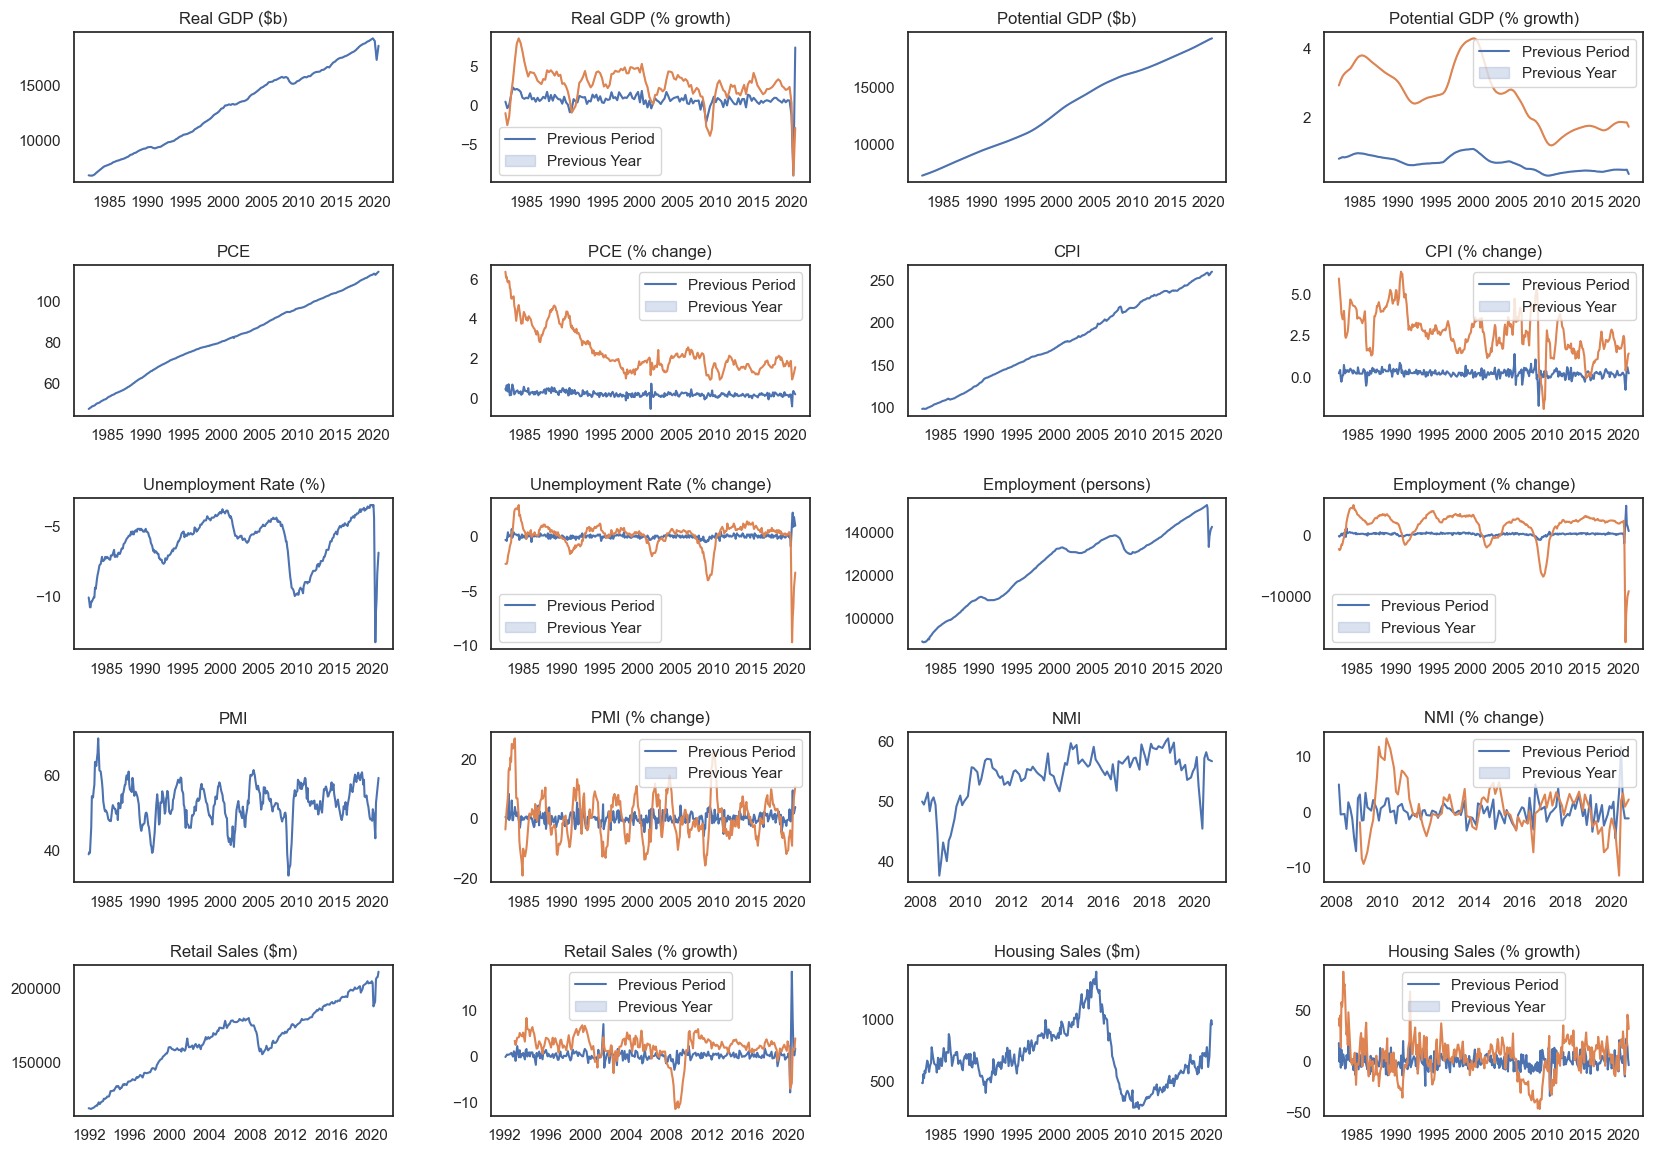

In [5]:
fig, axes = plt.subplots(5,4,figsize=(17,12))
sns.lineplot(x=meta_df['GDP_date'], y=meta_df['GDP_value'].values, ax=axes[0][0])
sns.lineplot(x=meta_df['GDP_date'], y=meta_df['GDP_diff_prev'].values, ax=axes[0][1])
sns.lineplot(x=meta_df['GDP_date'], y=meta_df['GDP_diff_year'].values, ax=axes[0][1])
sns.lineplot(x=meta_df['GDPPOT_date'], y=meta_df['GDPPOT_value'].values, ax=axes[0][2])
sns.lineplot(x=meta_df['GDPPOT_date'], y=meta_df['GDPPOT_diff_prev'].values, ax=axes[0][3])
sns.lineplot(x=meta_df['GDPPOT_date'], y=meta_df['GDPPOT_diff_year'].values, ax=axes[0][3])
sns.lineplot(x=meta_df['PCE_date'], y=meta_df['PCE_value'].values, ax=axes[1][0])
sns.lineplot(x=meta_df['PCE_date'], y=meta_df['PCE_diff_prev'].values, ax=axes[1][1])
sns.lineplot(x=meta_df['PCE_date'], y=meta_df['PCE_diff_year'].values, ax=axes[1][1])
sns.lineplot(x=meta_df['CPI_date'], y=meta_df['CPI_value'].values, ax=axes[1][2])
sns.lineplot(x=meta_df['CPI_date'], y=meta_df['CPI_diff_prev'].values, ax=axes[1][3])
sns.lineplot(x=meta_df['CPI_date'], y=meta_df['CPI_diff_year'].values, ax=axes[1][3])
sns.lineplot(x=meta_df['Unemp_date'], y=meta_df['Unemp_value'].values, ax=axes[2][0])
sns.lineplot(x=meta_df['Unemp_date'], y=meta_df['Unemp_diff_prev'].values, ax=axes[2][1])
sns.lineplot(x=meta_df['Unemp_date'], y=meta_df['Unemp_diff_year'].values, ax=axes[2][1])
sns.lineplot(x=meta_df['Employ_date'], y=meta_df['Employ_value'].values, ax=axes[2][2])
sns.lineplot(x=meta_df['Employ_date'], y=meta_df['Employ_diff_prev'].values, ax=axes[2][3])
sns.lineplot(x=meta_df['Employ_date'], y=meta_df['Employ_diff_year'].values, ax=axes[2][3])
sns.lineplot(x=meta_df['PMI_date'], y=meta_df['PMI_value'].values, ax=axes[3][0])
sns.lineplot(x=meta_df['PMI_date'], y=meta_df['PMI_diff_prev'].values, ax=axes[3][1])
sns.lineplot(x=meta_df['PMI_date'], y=meta_df['PMI_diff_year'].values, ax=axes[3][1])
sns.lineplot(x=meta_df['NMI_date'], y=meta_df['NMI_value'].values, ax=axes[3][2])
sns.lineplot(x=meta_df['NMI_date'], y=meta_df['NMI_diff_prev'].values, ax=axes[3][3])
sns.lineplot(x=meta_df['NMI_date'], y=meta_df['NMI_diff_year'].values, ax=axes[3][3])
sns.lineplot(x=meta_df['Rsales_date'], y=meta_df['Rsales_value'].values, ax=axes[4][0])
sns.lineplot(x=meta_df['Rsales_date'], y=meta_df['Rsales_diff_prev'].values, ax=axes[4][1])
sns.lineplot(x=meta_df['Rsales_date'], y=meta_df['Rsales_diff_year'].values, ax=axes[4][1])
sns.lineplot(x=meta_df['Hsales_date'], y=meta_df['Hsales_value'].values, ax=axes[4][2])
sns.lineplot(x=meta_df['Hsales_date'], y=meta_df['Hsales_diff_prev'].values, ax=axes[4][3])
sns.lineplot(x=meta_df['Hsales_date'], y=meta_df['Hsales_diff_year'].values, ax=axes[4][3])

for i in range(len(axes)):
    for j in range(len(axes[i])):
        axes[i][j].set_xlabel("")
        if (j == 1) | (j == 3):
            axes[i][j].legend(['Previous Period', 'Previous Year'])

axes[0][0].set_title('Real GDP ($b)')
axes[0][1].set_title('Real GDP (% growth)')
axes[0][2].set_title('Potential GDP ($b)')
axes[0][3].set_title('Potential GDP (% growth)')
axes[1][0].set_title('PCE')
axes[1][1].set_title('PCE (% change)')
axes[1][2].set_title('CPI')
axes[1][3].set_title('CPI (% change)')
axes[2][0].set_title('Unemployment Rate (%)')
axes[2][1].set_title('Unemployment Rate (% change)')
axes[2][2].set_title('Employment (persons)')
axes[2][3].set_title('Employment (% change)')
axes[3][0].set_title('PMI')
axes[3][1].set_title('PMI (% change)')
axes[3][2].set_title('NMI')
axes[3][3].set_title('NMI (% change)')
axes[4][0].set_title('Retail Sales ($m)')
axes[4][1].set_title('Retail Sales (% growth)')
axes[4][2].set_title('Housing Sales ($m)')
axes[4][3].set_title('Housing Sales (% growth)')


#ax.xaxis.set_major_locator(ticker.MultipleLocator(2000))
plt.tight_layout(pad=2.0)
plt.show()

# 2. Scraping FOMC Website
Run `fomc_get_data.py` to crawl and download texts from the wetbiste
<img src="../img/FomcWebsite.png" width="800">

### Sample statement

In [6]:
file = open('../data/preprocessed/text_no_split.pickle', 'rb')
text_df = pickle.load(file)
file.close()
# Convert nullable dtypes to standard dtypes for seaborn/numpy compatibility
def convert_dtypes(df):
    import pandas as pd, numpy as np
    result = df.copy()
    for col in result.columns:
        if pd.api.types.is_extension_array_dtype(result[col]):
            try:
                result[col] = result[col].astype(float)
            except (ValueError, TypeError):
                result[col] = result[col].astype(object)
        if result[col].dtype == object:
            result[col] = result[col].where(result[col].notna(), other=np.nan)
    return result

text_df = convert_dtypes(text_df)

In [7]:
print(text_df.loc[text_df['type']=='statement']['date'].iloc[-2].strftime('%Y-%m-%d'))
print('------------')
print(text_df.loc[text_df['type']=='statement']['text'].iloc[-2].replace(". ", ".\n\n"))

2020-11-05
------------
The COVID-19 pandemic is causing tremendous human and economic hardship across the United States and around the world.

Economic activity and employment have continued to recover but remain well below their levels at the beginning of the year.

Weaker demand and earlier declines in oil prices have been holding down consumer price inflation.

Overall financial conditions remain accommodative, in part reflecting policy measures to support the economy and the flow of credit to U.S.

households and businesses.

The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run.

With inflation running persistently below this longer-run goal, the Committee will aim to achieve inflation moderately above 2 percent for some time so that inflation averages 2 percent over time and longer-term inflation expectations remain well anchored at 2 percent.

The Committee expects to maintain an accommodative stance of monetary policy unti

### Sample minutes

In [8]:
print(text_df.loc[text_df['type']=='minutes']['date'].iloc[-1].strftime('%Y-%m-%d'))
print('------------')
print(text_df.loc[text_df['type']=='minutes']['text'].iloc[-1].replace(". ", ".\n\n"))

2020-09-16
------------
"Thomas was unquestionably one of the great economic minds of his generation, and his research has been central to some of our biggest discussions and policy actions over the past several years.

He had a rare and underappreciated gift for translating arcane and academic theory into real world practice.

That ability made a real difference in the conduct and communication of monetary policy.

From his work on r*, to the balance sheet, to leading the steering committee for our monetary policy review, Thomas Laubach's intellectual fingerprints are all over the Committee's decisions that will define this era of the Federal Reserve.

Thomas was also an exceptional colleague, leader, and friend.

No one here will be surprised to know that as condolences pour in, the admiration for his kindness and equanimity match, if not exceed, the esteem for his intellect.

Thomas was a model of leadership who fiercely believed that every member of his team is critical to our coll

In [9]:
print(text_df.loc[text_df['type']=='presconf_script']['date'].iloc[-1].strftime('%Y-%m-%d'))
print('------------')
print(text_df.loc[text_df['type']=='presconf_script']['text'].iloc[-1].replace(". ", ".\n\n"))

2020-11-05
------------
 Good afternoon.

  At the Federal Reserve, we are strongly committed to achieving the monetary policy goals that Congress has given us—maximum employment and price stability.

 Since the beginning of the pandemic, we have taken forceful actions to provide relief and stability, to ensure that the recovery will be as strong as possible, and to limit lasting damage to the economy.

 Today, my colleagues on the Federal Open Market Committee and I reaffirmed our commitment to support the economy in this challenging time.

 Economic activity has continued to recover from its depressed second-quarter level.

 The reopening of the economy led to a rapid rebound in activity, and real GDP rose at an annual rate of 33 percent in the third quarter.

 In recent months, however, the pace of improvement has moderated.

 Household spending on goods, especially durable goods, has been strong and has moved above its pre-pandemic level.

 In contrast, spending on services remains

Text(0.5, 1.0, 'The number of text data')

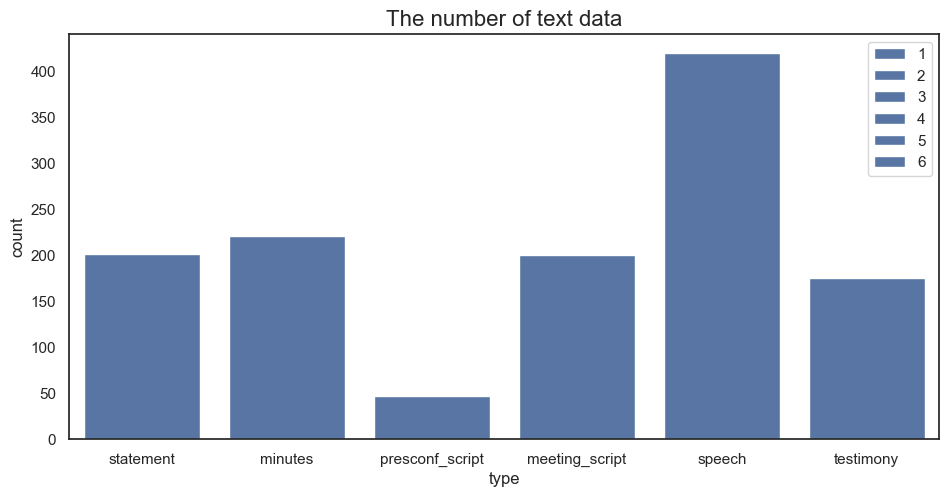

In [10]:
kwargs={'label': [1,2,3,4,5,6]}
plt.figure(figsize=(10,5))
sns.countplot(x='type', data=text_df.groupby(by=['type', 'date']).count().reset_index(),
             order=['statement', 'minutes', 'presconf_script', 'meeting_script', 'speech', 'testimony'], **kwargs)
plt.title('The number of text data', fontsize=16)

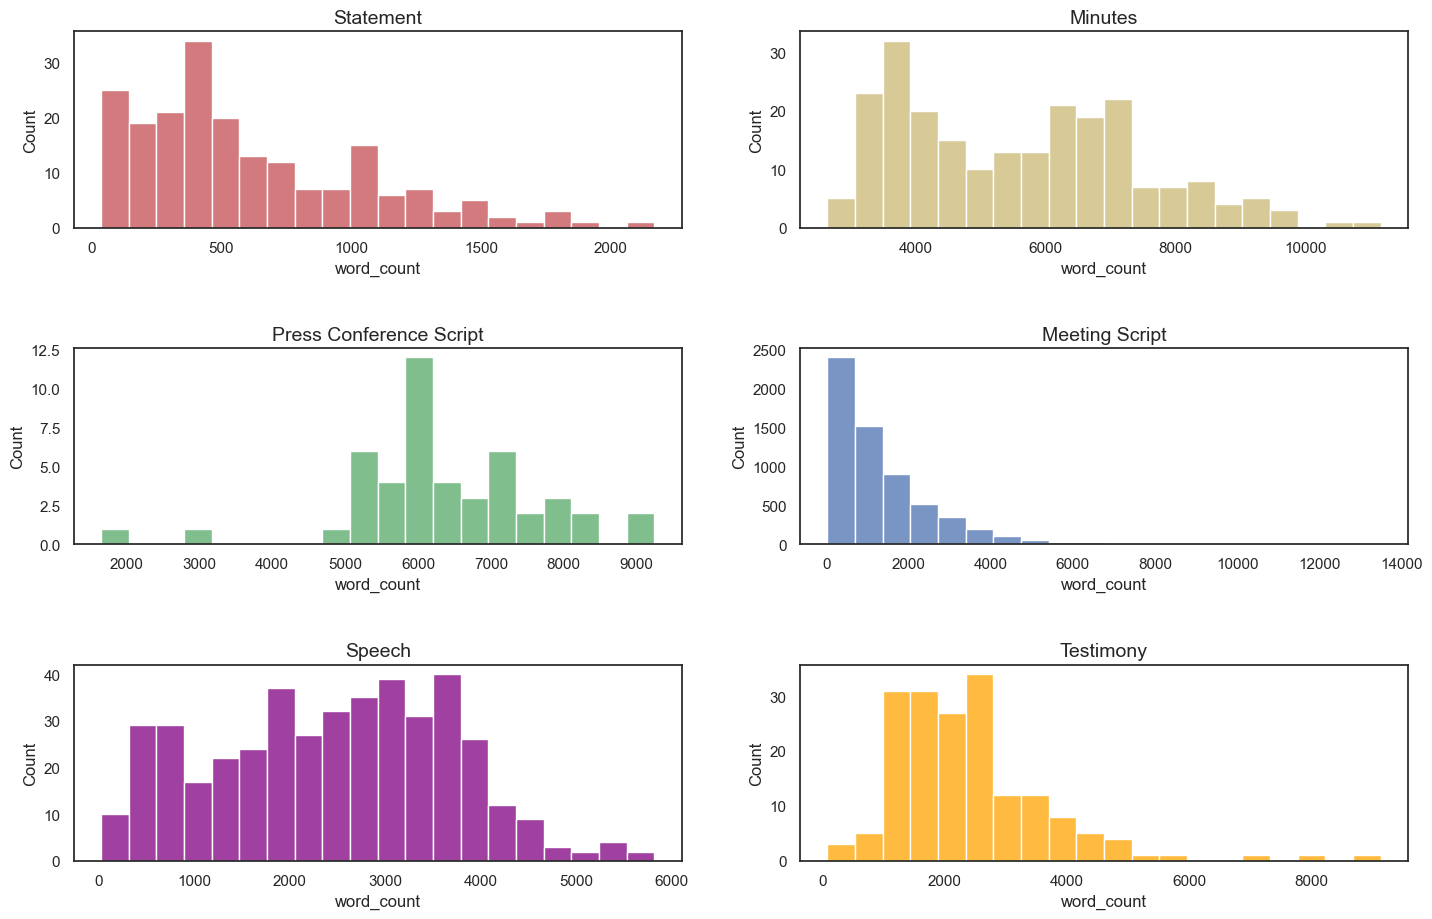

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(15,10))
sns.histplot(text_df.loc[text_df['type'] == 'statement']['word_count'], bins=20, ax=axes[0][0], color='r')
sns.histplot(text_df.loc[text_df['type'] == 'minutes']['word_count'], bins=20, ax=axes[0][1], color='y')
sns.histplot(text_df.loc[text_df['type'] == 'presconf_script']['word_count'], bins=20, ax=axes[1][0], color='g')
sns.histplot(text_df.loc[text_df['type'] == 'meeting_script']['word_count'], bins=20, ax=axes[1][1], color='b')
sns.histplot(text_df.loc[text_df['type'] == 'speech']['word_count'], bins=20, ax=axes[2][0], color='purple')
sns.histplot(text_df.loc[text_df['type'] == 'testimony']['word_count'], bins=20, ax=axes[2][1], color='orange')
axes[0][0].set_title("Statement", fontsize=14)
axes[0][1].set_title("Minutes", fontsize=14)
axes[1][0].set_title("Press Conference Script", fontsize=14)
axes[1][1].set_title("Meeting Script", fontsize=14)
axes[2][0].set_title("Speech", fontsize=14)
axes[2][1].set_title("Testimony", fontsize=14)
fig.tight_layout(pad=3.0)
plt.show()

# 3. Preliminary Analysis of Statement Sentiment by Lexicon
Analyse statement by Loughran and McDonald word list to see if the relationship between economy and net sentiment.

The detail analysis can be found on `1_FOMC_Analysis_Preliminary.ipynb`

In [12]:
file = open("../data/train_data/text_df.pickle", "rb")
Data = pickle.load(file)
file.close()

In [13]:
Data.columns

Index(['type', 'date', 'title', 'speaker', 'word_count', 'decision', 'rate',
       'next_meeting', 'next_decision', 'next_rate', 'text', 'tone_score',
       'word_count', 'n_pos_words', 'n_neg_words', 'pos_words', 'neg_words',
       'tokenized', 'token_ids', 'tfidf_Negative', 'tfidf_Positive',
       'tfidf_Uncertainty', 'tfidf_Litigious', 'tfidf_StrongModal',
       'tfidf_Constraining'],
      dtype='object')

In [14]:
stmt_df = Data.loc[Data['type']=='statement'].sort_values(['date']).set_index('date')

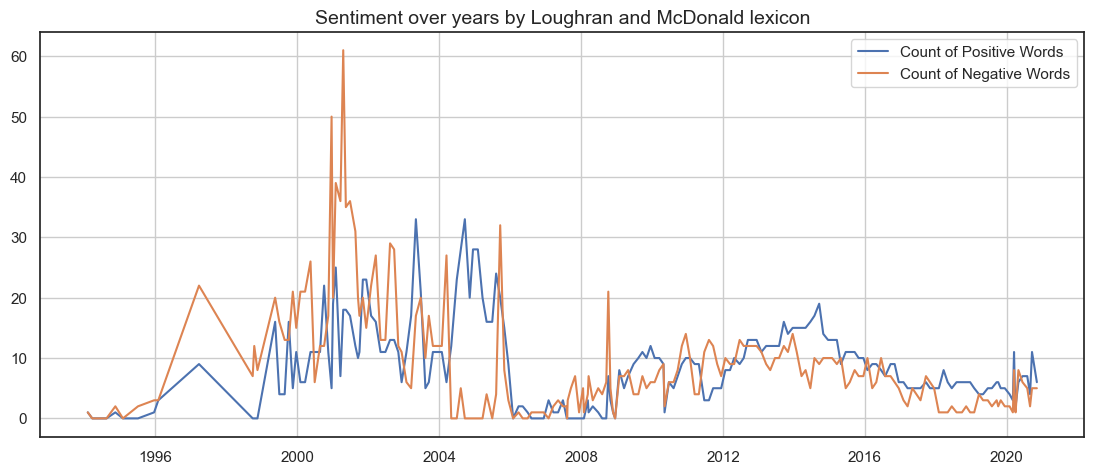

In [15]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(stmt_df[['n_pos_words', 'n_neg_words']]) 
plt.title('Sentiment over years by Loughran and McDonald lexicon', fontsize=14)
plt.legend(['Count of Positive Words', 'Count of Negative Words'])
ax.grid(True)

plt.show()

In [16]:
DotCom = np.logical_and(stmt_df.index > '2000-03', stmt_df.index < '2002-10') #Dot-com bubble
OhEight = np.logical_and(stmt_df.index > '2007-04', stmt_df.index < '2009-03') #Financial crisis of 2007–2008
EuroDebt = np.logical_and(stmt_df.index > '2010-09', stmt_df.index < '2012-09') #European debt crisis
Asian = np.logical_and(stmt_df.index > '2015-01', stmt_df.index < '2016-06') #2015–16 Chinese stock market turbulence
Corona = np.logical_and(stmt_df.index > '2020-03', stmt_df.index < '2020-12') #Coronavirus
Recessions = np.logical_or.reduce((DotCom, OhEight, EuroDebt, Asian, Corona))

Greenspan = np.logical_and(stmt_df.index > '1987-08-11', stmt_df.index < '2006-01-31')
Bernanke = np.logical_and(stmt_df.index > '2006-02-01', stmt_df.index < '2014-01-31')
Yellen = np.logical_and(stmt_df.index > '2014-02-03', stmt_df.index < '2018-02-03')
Powell = np.logical_and(stmt_df.index > '2018-02-05', stmt_df.index < '2022-02-05')
chair = np.logical_or.reduce((Greenspan, Yellen))


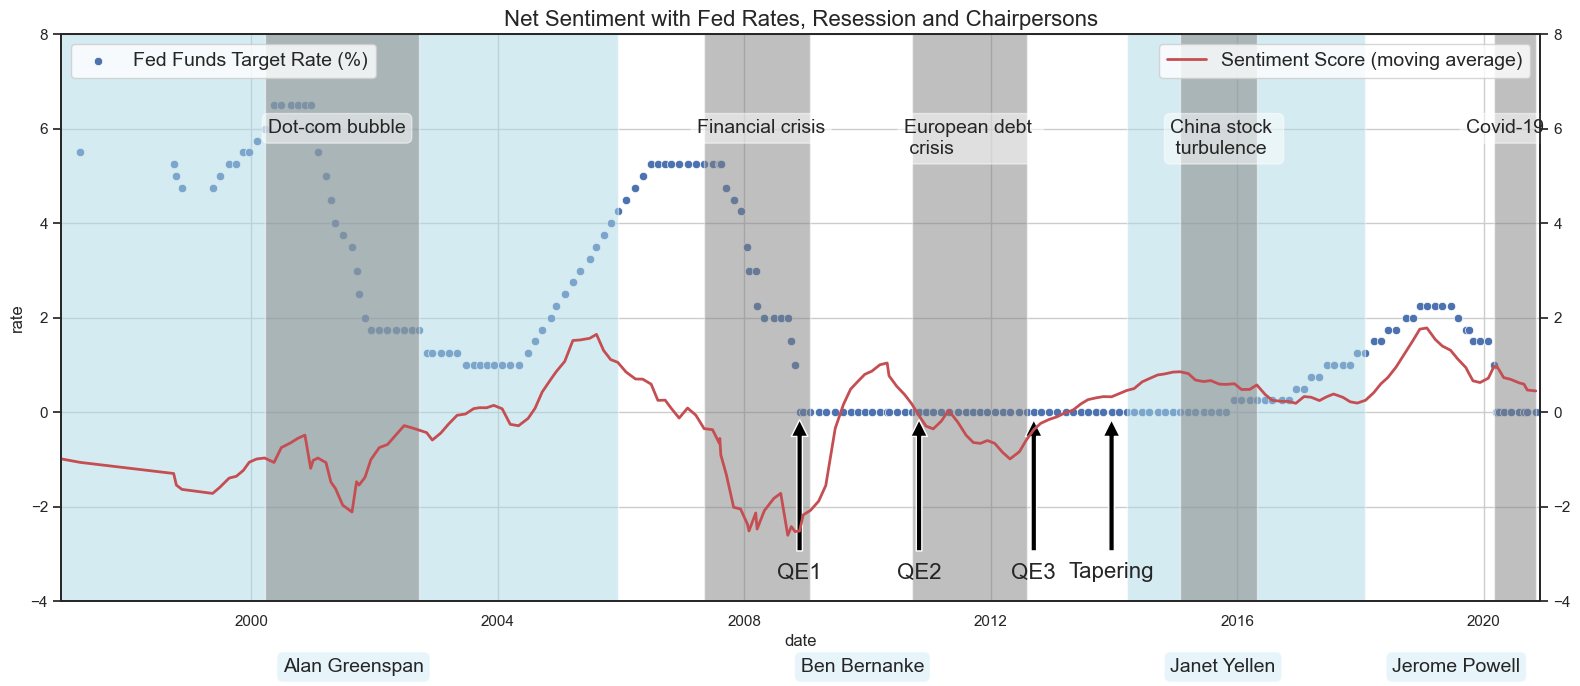

In [17]:
Window = 8
CompToMA = stmt_df['tone_score'].rolling(Window).mean()

fig, ax = plt.subplots(figsize=(17,7))
sns.scatterplot(x=stmt_df.index.get_level_values(0), y=stmt_df['rate'], ax=ax)
ax2 = ax.twinx() 
ax2.plot(stmt_df.index, CompToMA, c = 'r', linewidth= 2.0)
ax.legend(['Fed Funds Target Rate (%)'], loc=2, fontsize=14)
ax2.legend(['Sentiment Score (moving average)'], loc=1, fontsize=14)
ax.set_xlim(pd.Timestamp('1996-12'), pd.Timestamp('2020-12'))
ax.set_ylim(-4, 8)
ax2.set_ylim(-4, 8)
ax.grid(True)

import matplotlib.transforms as mtransforms
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
theta = 0.9
ax.fill_between(stmt_df.index, 0, 10, where = chair, facecolor='lightblue', alpha=0.5, transform=trans)
ax.fill_between(stmt_df.index, 0, 10, where = Recessions, facecolor='grey', alpha=0.5, transform=trans)

props = dict(boxstyle='round', facecolor='skyblue', alpha=0.2)
ax.text(0.15, -0.1, "Alan Greenspan", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)
ax.text(0.50, -0.1, "Ben Bernanke", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)
ax.text(0.75, -0.1, "Janet Yellen", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)
ax.text(0.90, -0.1, "Jerome Powell", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)

props = dict(boxstyle='round', facecolor='white', alpha=0.5)
ax.text(0.14, 0.85, "Dot-com bubble", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)
ax.text(0.43, 0.85, "Financial crisis", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)
ax.text(0.57, 0.85, "European debt \n crisis", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)
ax.text(0.75, 0.85, "China stock \n turbulence", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)
ax.text(0.95, 0.85, "Covid-19", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)


arrow_style = dict(facecolor='black', shrink=0.05)
ax.annotate('QE1', xy=(pd.Timestamp('2008-11-25'), 0), xytext=(pd.Timestamp('2008-11-25'), -3.5), size=16, ha='center', arrowprops=arrow_style)
ax.annotate('QE2', xy=(pd.Timestamp('2010-11-03'), 0), xytext=(pd.Timestamp('2010-11-03'), -3.5), size=16, ha='center', arrowprops=arrow_style)
ax.annotate('QE3', xy=(pd.Timestamp('2012-09-13'), 0), xytext=(pd.Timestamp('2012-09-13'), -3.5), size=16, ha='center', arrowprops=arrow_style)
ax.annotate('Tapering', xy=(pd.Timestamp('2013-12-18'), 0), xytext=(pd.Timestamp('2013-12-18'), -3.5), size=16, ha='center', arrowprops=arrow_style)

plt.title('Net Sentiment with Fed Rates, Resession and Chairpersons', fontsize=16)
plt.show()

# 4. Process economic indices data
The details can be found on `2_FOMC_Analysis_Preprocess_NonText.ipynb` and `4_FOMC_Analysis_EDA_NonText.ipynb`

## Taylor Rule
As a part of feature engineering, calculate taylor rules and see whether the first derivatives and difference from FED rate could be used. FED has released how policymakers use economic indices data, so try to calculate them from raw data. <BR />
https://www.federalreserve.gov/monetarypolicy/policy-rules-and-how-policymakers-use-them.htm

<img src='../img/taylor_rule.png' width="800">

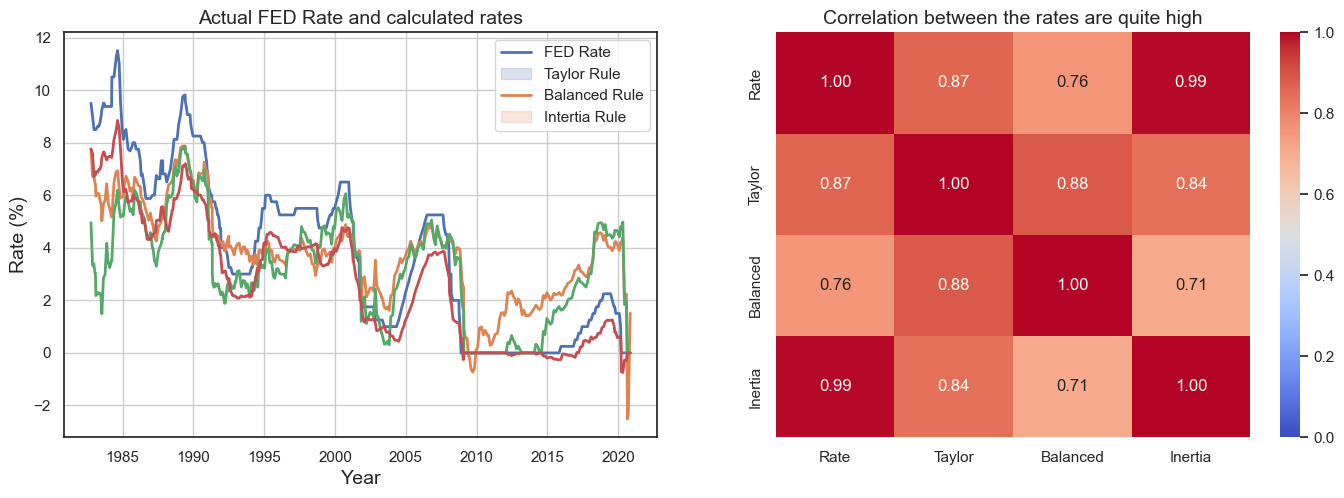

In [18]:
taylor=meta_df[['Rate', 'Taylor', 'Balanced', 'Inertia']]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=taylor, dashes=False, lw=2, ax=ax1)
ax1.grid(True)
ax1.set_title('Actual FED Rate and calculated rates', fontsize=14)
ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Rate (%)', fontsize=14)
ax1.legend(['FED Rate', 'Taylor Rule', 'Balanced Rule', 'Intertia Rule'])
sns.heatmap(taylor.astype(float).corr(), cmap="coolwarm", annot=True, fmt=".2f", vmin=0, vmax=1, ax=ax2)
ax2.set_title('Correlation between the rates are quite high', fontsize=14)
plt.show()

## Select features from meta data
Create moving average over different period, check correlation with Rate Decision (Raise/Hold/Lower) and select which features would be used as inputs for training. Also, impute the missing values.

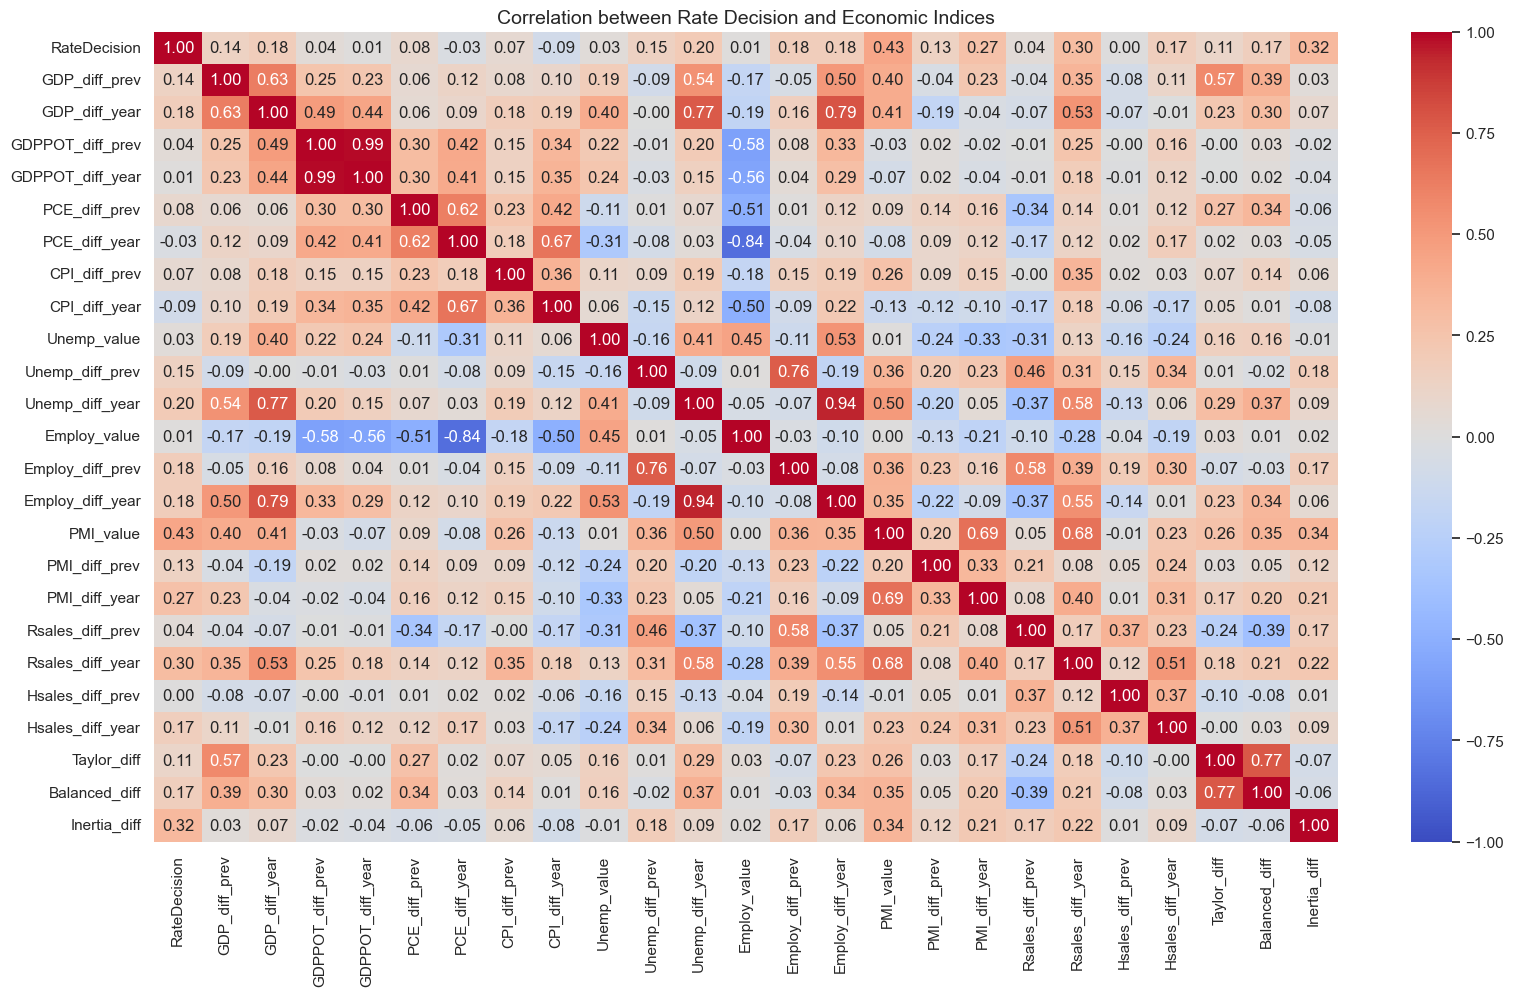

In [19]:
corr_columns = ['RateDecision', 'GDP_diff_prev', 'GDP_diff_year', 'GDPPOT_diff_prev', 'GDPPOT_diff_year',
                'PCE_diff_prev', 'PCE_diff_year', 'CPI_diff_prev', 'CPI_diff_year', 
                'Unemp_value', 'Unemp_diff_prev', 'Unemp_diff_year',
                'Employ_value', 'Employ_diff_prev', 'Employ_diff_year',
                'PMI_value', 'PMI_diff_prev', 'PMI_diff_year', 
                'Rsales_diff_prev', 'Rsales_diff_year', 'Hsales_diff_prev', 'Hsales_diff_year',
                'Taylor_diff', 'Balanced_diff', 'Inertia_diff']

fig, ax = plt.subplots(1, 1, figsize=(17, 10))

sns.heatmap(meta_df[corr_columns].astype(float).corr(), cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between Rate Decision and Economic Indices", fontsize=14)
plt.show()

/var/folders/tm/9p4kvlxn655cx6jpz_y9gxj40000gp/T/ipykernel_43618/878107317.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(meta_df['PMI_value'][(meta_df["RateDecision"] == -1) & (meta_df['PMI_value'].notnull())], ax=ax1, color="Red", shade=True)
/var/folders/tm/9p4kvlxn655cx6jpz_y9gxj40000gp/T/ipykernel_43618/878107317.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(meta_df['PMI_value'][(meta_df["RateDecision"] == 0) & (meta_df['PMI_value'].notnull())], ax=ax1, color="Gray", shade=True)
/var/folders/tm/9p4kvlxn655cx6jpz_y9gxj40000gp/T/ipykernel_43618/878107317.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(m

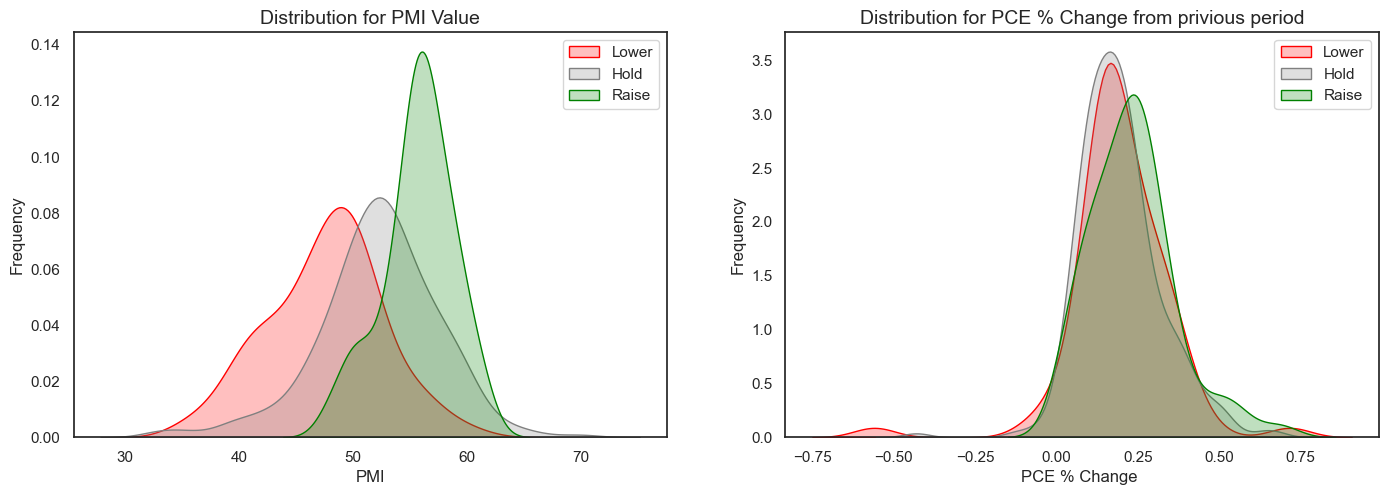

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(meta_df['PMI_value'][(meta_df["RateDecision"] == -1) & (meta_df['PMI_value'].notnull())], ax=ax1, color="Red", shade=True)
sns.kdeplot(meta_df['PMI_value'][(meta_df["RateDecision"] == 0) & (meta_df['PMI_value'].notnull())], ax=ax1, color="Gray", shade=True)
sns.kdeplot(meta_df['PMI_value'][(meta_df["RateDecision"] == 1) & (meta_df['PMI_value'].notnull())], ax=ax1, color="Green", shade=True)
ax1.set_xlabel('PMI')
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution for PMI Value", fontsize=14)
ax1.legend(["Lower", "Hold", "Raise"])
sns.kdeplot(meta_df['PCE_diff_prev'][(meta_df["RateDecision"] == -1) & (meta_df['PCE_diff_prev'].notnull())], ax=ax2, color="Red", shade=True)
sns.kdeplot(meta_df['PCE_diff_prev'][(meta_df["RateDecision"] == 0) & (meta_df['PCE_diff_prev'].notnull())], ax=ax2, color="Gray", shade=True)
sns.kdeplot(meta_df['PCE_diff_prev'][(meta_df["RateDecision"] == 1) & (meta_df['PCE_diff_prev'].notnull())], ax=ax2, color="Green", shade=True)
ax2.set_xlabel('PCE % Change ')
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution for PCE % Change from privious period", fontsize=14)
ax2.legend(["Lower", "Hold", "Raise"])
plt.show()


# 5. Process text data
The details can be found in `3_FOMC_Analysis_Preprocess_Text.ipynb`

<img src="../img/text_process.png" width="800" align="left">

In [21]:
file = open("../data/train_data/train_df.pickle", "rb")
train_df = pickle.load(file)
file.close()

In [22]:
file = open("../data/FOMC/statement.pickle", "rb")
statement_df = pickle.load(file)
file.close()
print(statement_df.iloc[-2]['contents'].replace("\n[SECTION]\n", ""))

The Federal Reserve, the central bank of the United States, provides the nation with a safe, flexible, and stable monetary and financial system.

Federal Open Market Committee

Monetary Policy Principles and Practice

Policy Implementation

Reports

Review of Monetary Policy Strategy, Tools, and Communications

Institution Supervision

Reports

Reporting Forms

Supervision & Regulation Letters

Banking Applications & Legal Developments

Regulatory Resources

Banking & Data Structure

Regulations & Statutes

Payment Policies

Reserve Bank Payment Services & Data

Financial Market Utilities & Infrastructures

Research, Committees, and Forums

Working Papers and Notes

Models and Tools

Bank Assets and Liabilities

Bank Structure Data

Business Finance

Dealer Financing Terms

Exchange Rates and International Data

Financial Accounts

Household Finance

Industrial Activity

Interest Rates

Micro Data Reference Manual (MDRM)

Money Stock and Reserve Balances

Other

Regulations

Supervisio

In [23]:
print(stmt_df.loc['2020-04-29']['text'])

The coronavirus outbreak is causing tremendous human and economic hardship across the United States and around the world. The virus and the measures taken to protect public health are inducing sharp declines in economic activity and a surge in job losses. Weaker demand and significantly lower oil prices are holding down consumer price inflation. The disruptions to economic activity here and abroad have significantly affected financial conditions and have impaired the flow of credit to U.S. households and businesses. The ongoing public health crisis will weigh heavily on economic activity, employment, and inflation in the near term, and poses considerable risks to the economic outlook over the medium term. In light of these developments, the Committee decided to maintain the target range for the federal funds rate at 0 to 1/4 percent. The Committee expects to maintain this target range until it is confident that the economy has weathered recent events and is on track to achieve its maxi

In [24]:
print(stmt_df.loc['2020-04-29']['tokenized'])

['the', 'coronavirus', 'outbreak', 'cause', 'tremendous', 'human', 'economic', 'hardship', 'across', 'unite', 'state', 'around', 'world', 'the', 'virus', 'measure', 'take', 'protect', 'public', 'health', 'induce', 'sharp', 'decline', 'economic', 'activity', 'surge', 'job', 'loss', 'weaker', 'demand', 'significantly', 'lower', 'oil', 'price', 'hold', 'consumer', 'price', 'inflation', 'the', 'disruption', 'economic', 'activity', 'abroad', 'significantly', 'affect', 'financial', 'condition', 'impair', 'flow', 'credit', 'household', 'business', 'the', 'ongoing', 'public', 'health', 'crisis', 'weigh', 'heavily', 'economic', 'activity', 'employment', 'inflation', 'near', 'term', 'pose', 'considerable', 'risk', 'economic', 'outlook', 'medium', 'term', 'in', 'light', 'development', 'committee', 'decide', 'maintain', 'target', 'range', 'federal', 'fund', 'rate', 'percent', 'the', 'committee', 'expect', 'maintain', 'target', 'range', 'confident', 'economy', 'weather', 'recent', 'event', 'track',

In [25]:
print(stmt_df.loc['2020-04-29']['token_ids'])

[17, 1280, 1281, 1072, 1310, 1311, 37, 1236, 1312, 198, 199, 158, 1313, 17, 1314, 83, 26, 1315, 1286, 1287, 481, 1080, 117, 37, 88, 1316, 320, 713, 938, 161, 322, 206, 633, 147, 394, 425, 147, 98, 17, 761, 37, 88, 510, 322, 1119, 202, 47, 1317, 1288, 345, 418, 417, 17, 253, 1286, 1287, 924, 518, 1318, 37, 88, 540, 98, 308, 309, 408, 517, 163, 37, 307, 1092, 309, 51, 159, 260, 9, 10, 386, 268, 989, 6, 118, 24, 119, 17, 9, 19, 386, 268, 989, 1206, 166, 1173, 140, 538, 1285, 680, 413, 540, 147, 370, 369, 17, 9, 276, 436, 1214, 621, 312, 37, 307, 286, 312, 79, 1286, 1287, 401, 204, 260, 691, 98, 14, 698, 966, 821, 743, 475, 166, 51, 1135, 348, 894, 218, 114, 31, 32, 33, 9, 366, 188, 19, 37, 47, 1067, 413, 540, 773, 358, 119, 98, 773, 50, 1166, 26, 351, 1009, 989, 312, 286, 83, 252, 8, 47, 631, 98, 14, 98, 128, 662, 202, 1204, 260, 552, 475, 1288, 345, 418, 417, 6, 15, 276, 447, 860, 547, 867, 869, 1017, 547, 889, 258, 475, 363, 8, 293, 100, 101, 136, 1294, 32, 33, 828, 202, 47, 51, 734, 7,

# 6. Build and Train Models
Take textual inputs and meta inputs to predict three classes: Raise, Hold or Lower
<img src="../img/model_overview.png" width="900">

The models are the same as Financial News / Tweets sentiment analysis but include meta inputs and concatinate them.
<img src="../img/model_0.png" width="900">
<img src="../img/model_A.png" width="900">
<img src="../img/model_B.png" width="900">
<img src="../img/model_C.png" width="900">
<img src="../img/model_D.png" width="900">
<img src="../img/model_E.png" width="900">
<img src="../img/model_F.png" width="900">


# Final Result

Due to the nature of long text per data and very small data set availability, the result was different from financial news and tweets analysis.
Simple lexicon approach with cosine similarity works well and better than more complex models as complex ones could not learn enough with limited data.
Finally, use of the trained BERT model to extract sentence-wise sentiment as inputs to the classification task outperformed the lexicon approach, which shows the sentiment analysis by BERT model could provide some meaningful insight to predict the FOMC decision.

As a future work, there're two main areas to improve:
1. Tackle the lack of enough training data - The models have clearly overfitted to train samples and failed to generalize well, espicially boosting algorithms are prone to overfitting. Hyperparameter tuning and imputation was considered there. In addition, configuraing the model and splitting data to augument the training data by synthetic approach could potentially benefitial. 
2. Improve input text quality - The input texts contain a lot of irrelevant paragraphs, which have nothing to to with FED target rate decision. For example, there are information about regulations, organisation structure and infrastructures. Filtering out less relevant inputs will improve the accuracy of the model prediction as well as training efficiency.

In [26]:
final_result_dict = {
    'model': ["Baseline"]*2 + ["A: Cosine Similarity"]*2 + ["B: Tfidf"]*2 + ["C: LSTM"]*2 + ["D: LSTM + GloVe"]*2 + ["E: BERT"]*2 + ["F: Prediction by BERT"]*2,
    'metrics': ["Accuracy", "F1 Score"]*7,
    'score': [0.63, 0.50] + [0.78, 0.67] + [0.67, 0.33] + [0.54, 0.24] + [0.63, 0.41] + [0.59, 0.25] + [0.82, 0.73]
}
final_result = pd.DataFrame(final_result_dict)

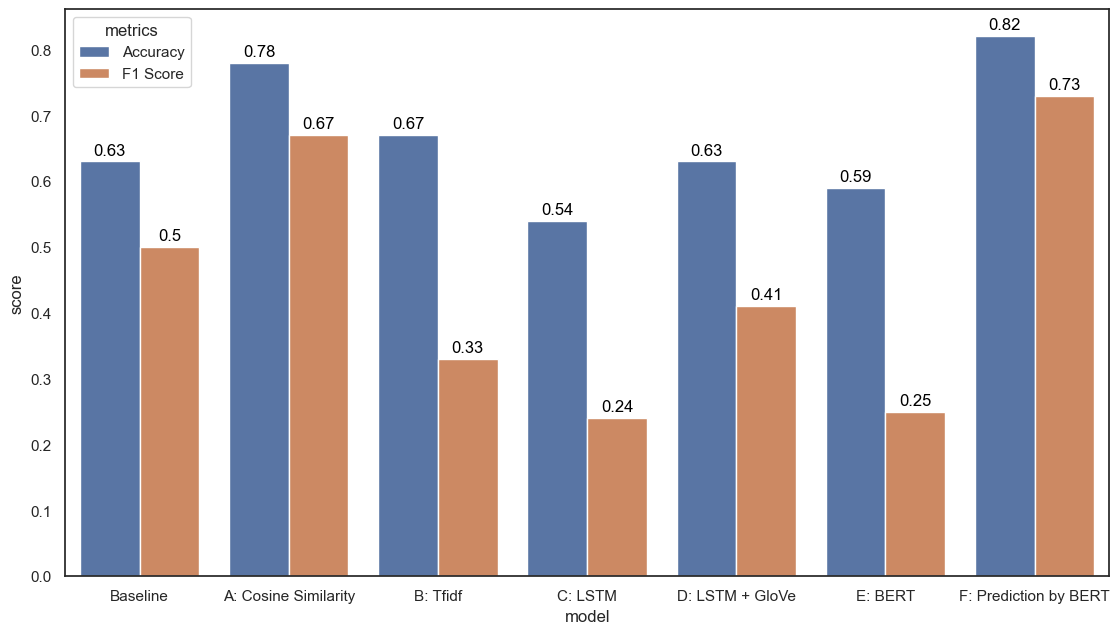

In [27]:
plt.figure(figsize=(12, 7))
g = sns.barplot(x='model', y='score', hue='metrics', data=final_result)
for index, row in final_result.loc[final_result['metrics']=='Accuracy'].iterrows():
    g.text(index/2-0.2, row.score+0.01, row.score, color='black', ha="center")
for index, row in final_result.loc[final_result['metrics']=='F1 Score'].iterrows():
    g.text(index/2-0.3, row.score+0.01, row.score, color='black', ha="center")
plt.show()
